# CSI 4142: fundamentals of data science


ASSIGNMENT 4: Unsupervised Learning
Clustering and Recommendations

# 2. INTRODUCTION

* **GOAL OF THE ANALYSIS**

The analysis uses unsupervised learning techniques to study the Movies Dataset, identifying movie metadata patterns and user behavior. The goal is to enhance content discovery and personalized recommendations, contributing to a better understanding of how unsupervised learning can enhance user experiences in platforms like streaming services and movie recommendation engines.
*   **AUDIENCE**

This analysis is intended for:

- **Movie Streaming Platforms & Content Providers**: The goal is to enhance user engagement by facilitating personalized content discovery and clustering of similar content.
- **Data Scientists & Machine Learning Engineers**: To apply and evaluate different unsupervised learning approaches on real-world datasets for clustering and recommendation.
- **Researchers in Recommender Systems**: To gain insights into combining similarity measures, content-based heuristics, and collaborative filtering for enhancing recommender performance.

# 2.1 DATASETS IMPORTS AND LOADING

In [ ]:
!pip install --upgrade numpy


In [ ]:
# Importation des bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error


In [ ]:
# Step 1 – Download the ZIP file from GitHub
url_zip = "https://github.com/Aichalfakir/Movies-Dataset-Unsupervised-Learning-Clustering-and-Recommendations/raw/main/movies_metadata.csv.zip"
os.system(f"wget {url_zip} -O movies_metadata.csv.zip")

# Step 2 – Extract the ZIP to a local folder
with zipfile.ZipFile("movies_metadata.csv.zip", "r") as zip_ref:
    zip_ref.extractall("movies_data")

# Step 3 – Load the CSV files
df_movies = pd.read_csv("movies_data/movies_metadata.csv.csv", low_memory=False)
df_ratings = pd.read_csv("movies_data/ratings_small.csv.csv")

# Step 4 – Preview and shapes
print("Movies Metadata Preview:")
display(df_movies.head())
print(f"Shape: {df_movies.shape[0]} rows × {df_movies.shape[1]} columns\n")

print("Ratings Dataset Preview:")
display(df_ratings.head())
print(f"Shape: {df_ratings.shape[0]} rows × {df_ratings.shape[1]} columns")


Movies Metadata Preview:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


Shape: 45466 rows × 24 columns

Ratings Dataset Preview:


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


Shape: 100004 rows × 4 columns


# 2.2 MISSING VALUES

In [ ]:
# Count missing values in both datasets
print("Missing Values in Movies Metadata:")
missing_movies = df_movies.isnull().sum()
print(missing_movies[missing_movies > 0].sort_values(ascending=False))

print("\n Missing Values in Ratings Dataset:")
missing_ratings = df_ratings.isnull().sum()
print(missing_ratings[missing_ratings > 0].sort_values(ascending=False))



Missing Values in Movies Metadata:
belongs_to_collection    40972
homepage                 37684
tagline                  25054
overview                   954
poster_path                386
runtime                    263
release_date                87
status                      87
imdb_id                     17
original_language           11
revenue                      6
title                        6
video                        6
vote_average                 6
spoken_languages             6
vote_count                   6
popularity                   5
production_companies         3
production_countries         3
dtype: int64

 Missing Values in Ratings Dataset:
Series([], dtype: int64)


# 2.3 REDUNDANCY

In [ ]:
# ====== Redundancy Check ======

# Check for duplicate rows
print(f"\n Duplicate rows in movies dataset: {df_movies.duplicated().sum()}")
print(f" Duplicate rows in ratings dataset: {df_ratings.duplicated().sum()}")

# Check for duplicated columns by name
print("\n Duplicated column names in movies dataset:")
print(df_movies.columns[df_movies.columns.duplicated()].tolist())


 Duplicate rows in movies dataset: 17
 Duplicate rows in ratings dataset: 0

 Duplicated column names in movies dataset:
[]


# 3. DATASETS DESCRIPTIONS


*   **NAME**: The Movies Dataset
*   **AUTHOR**: Rounak Banik
*   **PURPOSE**: The purpose of this dataset analysis is to:

1. Analyze movie features such as genre, language, budget, and popularity.
2. Explore user ratings and interactions with movies.
3. Identify missing data and prepare the datasets for recommendation systems.
4. Perform clustering based on movie metadata.
5. Build both content-based and collaborative recommendation models.

*   **SHAPE:**
 - `movies_metadata.csv`: **45,466 rows × 24 columns**  
 - `ratings_small.csv`: **100,004 rows × 4 columns**
*   **LIST OF FEATURES**:
#### `movies_metadata.csv`

| Column Name              | Description | Data Type |
|-------------------------|----------------------------------------------|--------------------------|
| adult                   | Indicates whether the movie is for adults           | Boolean                   |
| belongs_to_collection   | Movie collection the film belongs to                | Categorical (Nominal)     |
| budget                  | Budget for the movie                                | Numerical (Continuous)    |
| genres                  | List of genres (as dictionaries)                    | Categorical (JSON)        |
| homepage                | URL of the movie's homepage                         | Text / URL                |
| id                      | Unique movie identifier                             | Categorical (Nominal)     |
| imdb_id                 | IMDB identifier                                     | Categorical (Nominal)     |
| original_language       | Original language of the movie                      | Categorical (Nominal)     |
| original_title          | Original title of the movie                         | Categorical (Nominal)     |
| overview                | Short description of the movie                      | Text                      |
| popularity              | Popularity score                                    | Numerical (Continuous)    |
| poster_path             | Link to the movie's poster                          | Text / URL                |
| production_companies    | Production companies                                | Categorical (Nominal)     |
| production_countries    | Countries involved in production                    | Categorical (Nominal)     |
| release_date            | Date of release                                     | Date (String)             |
| revenue                 | Revenue generated by the movie                      | Numerical (Continuous)    |
| runtime                 | Duration of the movie in minutes                    | Numerical (Continuous)    |
| spoken_languages        | Languages spoken in the movie                       | Categorical (Nominal)     |
| status                  | Release status (e.g., Released)                     | Categorical (Nominal)     |
| tagline                 | Promotional tagline                                 | Text                      |
| title                   | Official title                                      | Categorical (Nominal)     |
| video                   | Video release flag                                  | Boolean                   |
| vote_average            | Average rating                                      | Numerical (Continuous)    |
| vote_count              | Total number of votes                               | Numerical (Discrete)      |


#### `ratings_small.csv`:
| Column Name              | Description | Data Type |
|-------------------------|----------------------------------------------|--------------------------|
| userId       | Unique identifier for each user      | Categorical (Nominal)   |
| movieId      | Movie identifier (foreign key)       | Categorical (Nominal)   |
| rating       | Rating given to the movie            | Numerical (Ordinal)     |
| timestamp    | Unix time of the rating              | Numerical (Discrete)    |



#### Missing Values

The `movies_metadata.csv.csv` dataset contains a significant number of missing values in several columns:

- `belongs_to_collection`: 40,972 missing entries
- `homepage`: 37,684 missing
- `tagline`: 25,054 missing
- Other relevant features with missing values include:
  - `overview` (954), `poster_path` (386), `runtime` (263), `release_date` (87), and `status` (87)
  - Even core fields like `title`, `revenue`, `vote_average`, `vote_count`, `popularity`, and `spoken_languages` have a small number of missing values (6 or less)

These will require either imputation, removal, or domain-informed handling.

The `ratings_small.csv` dataset contains **no missing values**.

---

#### Redundancy

- **Duplicate rows**:
  - `movies_metadata.csv`: **17 duplicate rows**
  - `ratings_small.csv`: **0 duplicate rows**

- No duplicate column names were found in either dataset.

# 4. Data preparation

In [ ]:
# 1. Convert column types
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')
df_movies['budget'] = pd.to_numeric(df_movies['budget'], errors='coerce')
df_movies['revenue'] = pd.to_numeric(df_movies['revenue'], errors='coerce')
df_movies['runtime'] = pd.to_numeric(df_movies['runtime'], errors='coerce')
df_movies['vote_average'] = pd.to_numeric(df_movies['vote_average'], errors='coerce')

# 2. Convert unhashable types to string
for col in df_movies.columns:
    if df_movies[col].apply(lambda x: isinstance(x, (dict, list, set))).any():
        df_movies[col] = df_movies[col].astype(str)

# 3. Remove duplicates
df_movies = df_movies.drop_duplicates()

# 4. Handle missing values for 'runtime' safely (no chained assignment)
df_movies['runtime'] = df_movies['runtime'].fillna(df_movies['runtime'].median())

# 5. Remove extreme outliers for budget and revenue
df_movies = df_movies[(df_movies['budget'] < 1e9) & (df_movies['revenue'] < 3e9)]

#  6. Confirm final shape
print("Shape finale du dataset nettoyé :", df_movies.shape)



Shape finale du dataset nettoyé : (45443, 24)


<ipython-input-10-38919ee79181>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['runtime'] = df_movies['runtime'].fillna(df_movies['runtime'].median())


In [ ]:
df_movies.to_csv("cleaned_movies_dataset.csv", index=False)


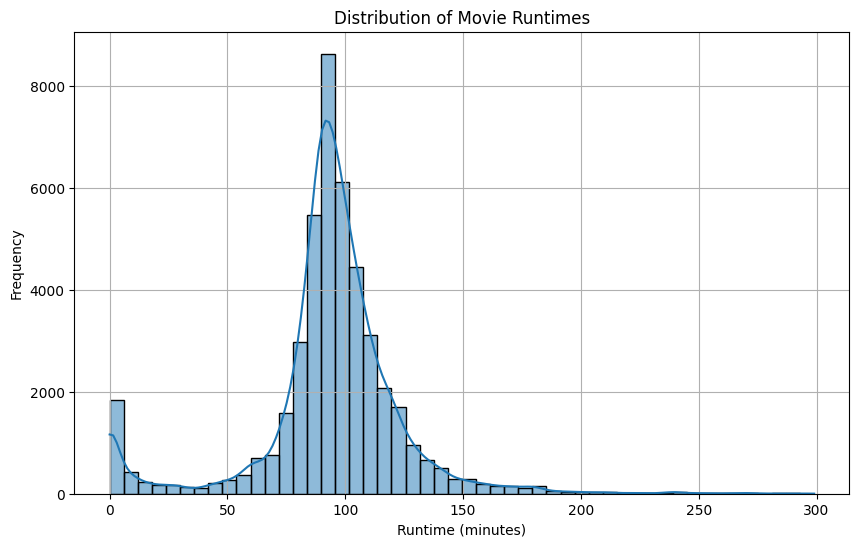

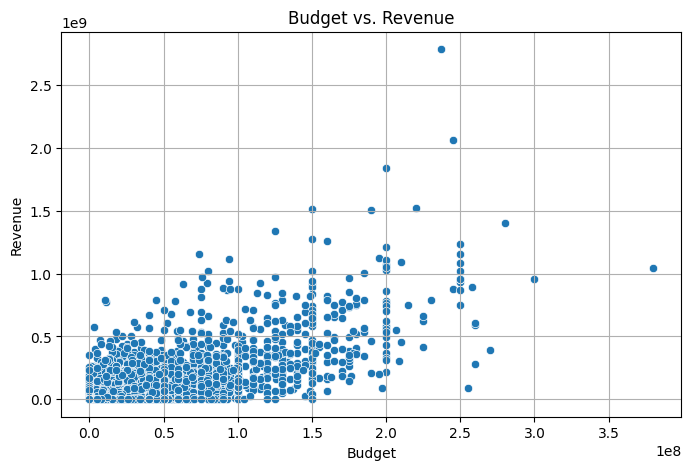

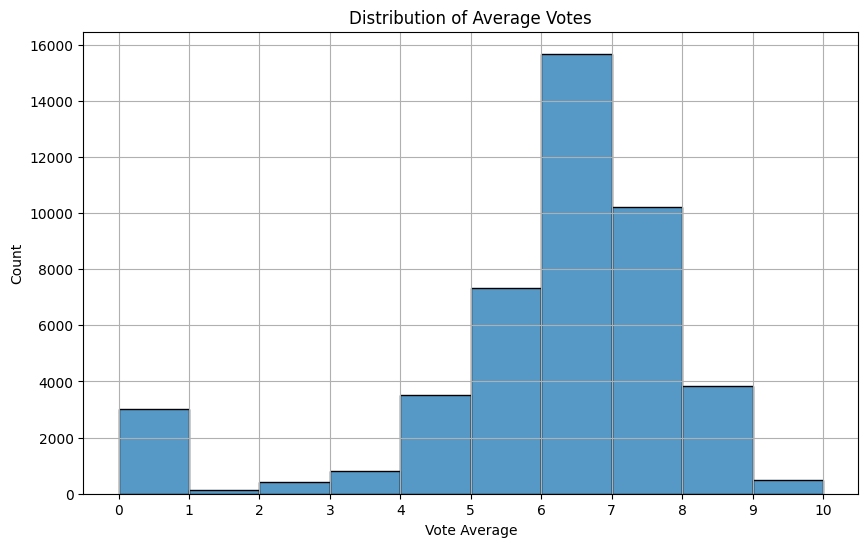

In [ ]:
# EDA Visualization

# Distribution of movie runtimes (filtered to remove outliers)
df_runtime_filtered = df_movies[df_movies['runtime'] < 300]

plt.figure(figsize=(10, 6))
sns.histplot(df_runtime_filtered['runtime'].dropna(), bins=50, kde=True)
plt.title("Distribution of Movie Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Budget vs. Revenue Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_movies, x='budget', y='revenue')
plt.title("Budget vs. Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# Distribution of Vote Averages (rounded to nearest integer)
plt.figure(figsize=(10, 6))
sns.histplot(df_movies['vote_average'].dropna().round(0), bins=10, kde=False)
plt.title("Distribution of Average Votes")
plt.xlabel("Vote Average")
plt.ylabel("Count")
plt.xticks(range(0, 11))
plt.grid(True)
plt.show()


# 5. Studies

In [ ]:
import pandas as pd

# Recharger le dataset nettoyé
df_movies = pd.read_csv("cleaned_movies_dataset.csv")

#### ***5.1) Study 1 – Similarity measures***

In [ ]:
# Jaccard Similarity (for genres)
def jaccard_similarity(set1, set2):
    set1, set2 = set(set1), set(set2)
    if not set1 or not set2:
        return 0
    return len(set1 & set2) / len(set1 | set2)

# Euclidean & Manhattan similarities (inverted distances)
def euclidean_similarity(x, y):
    return 1 / (1 + euclidean([x], [y]))

def manhattan_similarity(x, y):
    return 1 / (1 + cityblock([x], [y]))

# Cosine similarity
def cosine_sim(x, y):
    return cosine_similarity([[x]], [[y]])[0][0]

# Title similarity using SequenceMatcher (edit distance)
def title_similarity(title1, title2):
    return SequenceMatcher(None, str(title1).lower(), str(title2).lower()).ratio()

# Affichage des top 10 résultats
def show_top_similar(df, similarity_scores, title="Top Similar Items"):
    df_copy = df.copy()
    df_copy['similarity_score'] = similarity_scores
    top10 = df_copy.sort_values(by='similarity_score', ascending=False).head(10)
    return top10[['title', 'similarity_score', 'genres', 'runtime', 'budget', 'revenue']]


#### ***Request 1 – Find movies with similar genres to "Inception"***

In this query, we use the **Jaccard similarity** measure to compare movie genres.  
Each movie's genres are represented as a set, and we compute the Jaccard similarity between *Inception* and all other movies.

**Similarity Measure**: Jaccard  
**Attribute used**: `genres`  
**Reference movie**: *Inception*


In [ ]:
# Requête 1 : Genres similaires à "Inception"
ref_title = "Inception"
ref_genres = df_movies[df_movies['title'] == ref_title]['genres'].values[0]
scores_jaccard = df_movies['genres'].apply(lambda x: jaccard_similarity(ref_genres, x))
top10_genres = show_top_similar(df_movies, scores_jaccard, title="Similar Genres to Inception")
top10_genres


,title,similarity_score,genres,runtime,budget,revenue
42145,ISRA 88,1.000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 12, 'n...",119.0,0.0,0.0
7009,Paycheck,1.000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",119.0,60000000.0,96269812.0
38800,The Philadelphia Experiment,1.000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",85.0,0.0,0.0
15476,Inception,1.000000,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",148.0,160000000.0,825532764.0
8137,Sky Captain and the World of Tomorrow,1.000000,"[{'id': 9648, 'name': 'Mystery'}, {'id': 28, '...",107.0,70000000.0,57958696.0
7771,This Island Earth,0.974359,"[{'id': 9648, 'name': 'Mystery'}, {'id': 12, '...",87.0,800000.0,0.0
27899,Zenith,0.974359,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",93.0,0.0,0.0
157,Congo,0.974359,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",109.0,50000000.0,152022101.0
13498,Knowing,0.974359,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",121.0,50000000.0,155446362.0
4317,Final Fantasy: The Spirits Within,0.947368,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",106.0,137000000.0,85131830.0


#### ***Request 2 – Find movies with similar runtime to "The Godfather"***

In this query, we compute the **Manhattan distance** between the runtime of *The Godfather* and all other movies.  
This will help us find films with similar lengths.

**Similarity Measure**: Manhattan Distance  
**Attribute used**: `runtime`  
**Reference movie**: *The Godfather*


In [ ]:
# Requête 2 : Durée similaire à "The Godfather"
from scipy.spatial.distance import cityblock
ref_title = "The Godfather"
ref_runtime = df_movies[df_movies['title'] == ref_title]['runtime'].values[0]
scores_runtime = df_movies['runtime'].apply(lambda x: manhattan_similarity(ref_runtime, x))
top10_runtime = show_top_similar(df_movies, scores_runtime, title="Similar Runtime to The Godfather")
top10_runtime


,title,similarity_score,genres,runtime,budget,revenue
72,Les Miserables,1.0,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",175.0,0.0,0.0
45397,Arabian Nights,1.0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",175.0,0.0,0.0
1166,Once Upon a Time in the West,1.0,"[{'id': 37, 'name': 'Western'}]",175.0,5000000.0,5321508.0
15021,Karan Arjun,1.0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",175.0,0.0,0.0
8249,Alexander,1.0,"[{'id': 10752, 'name': 'War'}, {'id': 36, 'nam...",175.0,155000000.0,167298192.0
10740,The Temptations,1.0,"[{'id': 10402, 'name': 'Music'}, {'id': 18, 'n...",175.0,8000000.0,0.0
13547,With Fire and Sword,1.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 80, '...",175.0,0.0,0.0
45091,Sunstroke,1.0,"[{'id': 36, 'name': 'History'}, {'id': 18, 'na...",175.0,21000000.0,0.0
6347,Is Paris Burning?,1.0,"[{'id': 10752, 'name': 'War'}, {'id': 18, 'nam...",175.0,0.0,0.0
834,The Godfather,1.0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",175.0,6000000.0,245066411.0


#### ***Request 3–  Movies with Similar Budget to "Avatar"***

In this query, we aim to find movies that have a similar **budget** to **"Avatar"**.

**Similarity measure used:** Euclidean distance  
**Similarity score transformation:** `1 / (1 + euclidean(x, y))`

We compare budget values using a simple numerical distance, which helps identify movies with budgets close to that of **Avatar**.  
This allows us to retrieve the **Top 10 most similar movies by budget**.


In [ ]:
from scipy.spatial.distance import euclidean

ref_title = "Avatar"
ref_budget = df_movies[df_movies['title'] == ref_title]['budget'].values[0]

# Compute similarity scores using Euclidean distance
scores_budget = df_movies['budget'].apply(lambda x: 1 / (1 + euclidean([ref_budget], [x])))

# Display the Top 10 movies with the most similar budget
top10_budget = show_top_similar(df_movies, scores_budget, title="Similar Budget to Avatar")
top10_budget


,title,similarity_score,genres,runtime,budget,revenue
14547,Avatar,1.000000e+00,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",162.0,237000000.0,2.787965e+09
26548,Pirates of the Caribbean: Dead Men Tell No Tales,1.428571e-07,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",129.0,230000000.0,7.941920e+08
30745,Spectre,1.250000e-07,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",148.0,245000000.0,8.806746e+08
26543,Star Wars: The Force Awakens,1.250000e-07,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",136.0,245000000.0,2.068224e+09
12611,The Chronicles of Narnia: Prince Caspian,8.333333e-08,"[{'id': 12, 'name': 'Adventure'}, {'id': 10751...",150.0,225000000.0,4.196514e+08
21061,Man of Steel,8.333333e-08,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",143.0,225000000.0,6.628455e+08
18967,Men in Black 3,8.333333e-08,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",106.0,225000000.0,6.240268e+08
18247,The Dark Knight Rises,7.692307e-08,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",165.0,250000000.0,1.084939e+09
31056,Batman v Superman: Dawn of Justice,7.692307e-08,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",151.0,250000000.0,8.732602e+08
22050,The Hobbit: The Desolation of Smaug,7.692307e-08,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",161.0,250000000.0,9.584000e+08


####***Request 4 – Movies with Similar Revenue to Frozen***

In this query, we aim to find movies that have a similar **revenue** to *Frozen*.

**Similarity measure used**: Cosine distance  
**Similarity score transformation**: `1 / (1 + cosine(x, y))`

We use cosine similarity to compare revenue values as vectors, enabling us to assess the proximity between *Frozen* and other movies in terms of revenue.  
This method retrieves the **Top 10 most similar movies by revenue**.


In [ ]:
# Request 4 – Movies with Similar Revenue to "Frozen"
from scipy.spatial.distance import cosine

ref_title = "Frozen"
ref_revenue = df_movies[df_movies['title'] == ref_title]['revenue'].values[0]

# Compute similarity scores using Cosine similarity
scores_revenue = df_movies['revenue'].apply(lambda x: 1 / (1 + cosine([ref_revenue], [x])))

# Display the Top 10 movies with the most similar revenue
top10_revenue = show_top_similar(df_movies, scores_revenue, title="Similar Revenue to Frozen")
top10_revenue


/usr/local/lib/python3.11/dist-packages/scipy/spatial/distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


,title,similarity_score,genres,runtime,budget,revenue
45399,Antidur,1.0,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",91.0,5000000.0,1413000.0
0,Toy Story,1.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",81.0,30000000.0,373554033.0
1,Jumanji,1.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",104.0,65000000.0,262797249.0
3,Waiting to Exhale,1.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",127.0,16000000.0,81452156.0
4,Father of the Bride Part II,1.0,"[{'id': 35, 'name': 'Comedy'}]",106.0,0.0,76578911.0
5,Heat,1.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",170.0,60000000.0,187436818.0
8,Sudden Death,1.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",106.0,35000000.0,64350171.0
9,GoldenEye,1.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",130.0,58000000.0,352194034.0
10,The American President,1.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",106.0,62000000.0,107879496.0
12,Balto,1.0,"[{'id': 10751, 'name': 'Family'}, {'id': 16, '...",78.0,0.0,11348324.0


####***Request 5 – Movies with Similar Title to "Black Panther"***

In this query, we aim to find movies whose **titles** are similar to *"Black Panther"* using a **text-based similarity measure**.

-  **Similarity measure used:** Edit distance (Levenshtein distance)  
- **Similarity score transformation:**  `1 / (1 + edit_distance(x, y))`

We apply the Levenshtein edit distance to measure how many character changes are needed to transform one title into another. Lower distances yield higher similarity scores.  
This allows us to retrieve the **Top 10 movies with the most similar titles** to *"Black Panther"*.


In [ ]:
pip install python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.8 MB/s eta 0:00:00


In [ ]:
# Request 5 – Similar Title to "Black Panther"
import Levenshtein

def edit_distance(x, y):
    return Levenshtein.distance(str(x).lower(), str(y).lower())

ref_title = "Black Panther"
scores_title = df_movies['title'].apply(lambda x: 1 / (1 + edit_distance(ref_title, x)))

top10_title = show_top_similar(df_movies, scores_title, title="Similar Title to Black Panther")
top10_title


,title,similarity_score,genres,runtime,budget,revenue
12522,Black Peter,0.250000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",85.0,0.0,0.0
15644,Black Water,0.250000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",90.0,700.0,0.0
8038,Black Angel,0.200000,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",81.0,0.0,0.0
29777,Black Angel,0.200000,"[{'id': 18, 'name': 'Drama'}, {'id': 14, 'name...",25.0,25000.0,0.0
41323,Black Butler,0.200000,"[{'id': 27, 'name': 'Horror'}, {'id': 14, 'nam...",119.0,0.0,0.0
37461,Black Angel,0.200000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",128.0,0.0,0.0
41983,The Black Panther,0.200000,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",102.0,0.0,0.0
33806,Black Ransom,0.166667,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",93.0,0.0,0.0
33096,Black River,0.166667,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",86.0,0.0,0.0
16045,Black Death,0.166667,"[{'id': 18, 'name': 'Drama'}, {'id': 27, 'name...",102.0,0.0,265318.0


#### ***5.2) Study 2 – Clustering algorithms***

In this study, we apply unsupervised learning to group similar movies using **K-Means clustering**.  
We select a few numerical features from the dataset and visualize how movies are clustered based on those attributes.

**Clustering algorithm used:** K-Means  
**Features used:** `runtime`, `vote_average`, `budget`, `revenue`  
**Goal:** Identify patterns or groups of movies with similar characteristics


In [ ]:
# Feature selection for clustering
features_for_clustering = ['runtime', 'vote_average', 'budget', 'revenue']
X = df_movies[features_for_clustering]

# Handle missing values with median imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [ ]:
#  Apply KMeans clustering
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df_movies['cluster'] = clusters


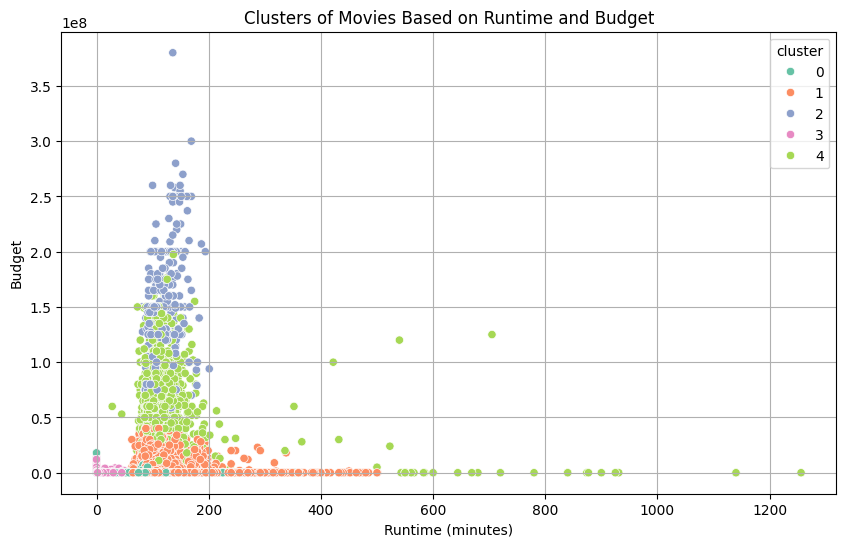

In [ ]:
# Visualize clusters using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_movies, x='runtime', y='budget', hue='cluster', palette='Set2')
plt.title('Clusters of Movies Based on Runtime and Budget')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Budget')
plt.grid(True)
plt.show()


###Cluster Interpretation

The scatter plot shows five distinct clusters of movies based on `runtime` and `budget`.  
We can interpret the clusters as follows:

-  **Cluster 0**: Movies with low budget and short runtime — likely independent or low-budget productions.
-  **Cluster 2**: Movies with high budget and standard runtime — likely blockbusters or studio films.
-  **Cluster 1**: Movies with average budget and average runtime — typical mainstream films.
-  **Cluster 3**: Very short runtime and near-zero budget — possibly trailers, TV episodes, or experimental content.
-  **Cluster 4**: Movies with unusual values — either extremely long runtime or outlier budgets.

 The clustering technique offers valuable insights into movie production scale and length, aiding in recommendation, analysis, and targeting specific content types.


#### ***5.3) Study 3 – Content-Based Recommendation System***

This study develops a recommendation system based on content similarity.
 It uses two heuristics:
 1. Jaccard similarity on movie genres.
 2. Euclidean distance on runtime and popularity.

The system returns the top 10 most similar movies.

**Similarity Heuristics (Domain Justified)**

Content-based filtering recommends items (movies, in this case) based on their attributes, rather than user preferences. The similarity between items is measured based on their characteristics. In the case of movie recommendation, two key types of similarity heuristics are used to find similar movies:

**Heuristic 1:** Genre Similarity (Cosine Similarity)

Explanation: Genres represent the main thematic characteristics of a movie. Movies with similar genres tend to have similar content and appeal to users who enjoy a specific type of film. By converting the genre data into a numerical representation using HashingVectorizer, we calculate the cosine similarity between movies. Cosine similarity measures the angle between two vectors, giving a score from 0 (no similarity) to 1 (identical).

**Domain Justification:** Genre similarity is commonly used in content-based filtering because users who enjoy a specific genre (e.g., action, drama, comedy) are likely to enjoy other movies within the same genre.

**Heuristic 2: Popularity and Runtime Similarity**

**Explanation:** This heuristic calculates similarity based on runtime (length of the movie) and popularity (how widely liked or rated a movie is). We calculate the Euclidean distance between the target movie and all other movies based on these two features. The idea is that movies with similar runtime and popularity are likely to have similar audience appeal.

**Domain Justification:** Popularity and runtime are simple yet effective attributes in content-based filtering. Users may prefer movies of similar length or be more inclined to watch movies that have a similar level of popularity or attention.

In [ ]:
def parse_genres(genre_str):
    try:
        genres = genres = json.loads(genre_str)
        return " ".join([g['name'] for g in genres]) if isinstance(genres, list) else ""
    except:
        return ""

df_movies['genres'] = df_movies['genres'].apply(parse_genres)

# Compute Similarity Matrices
vectorizer = HashingVectorizer(n_features=500, alternate_sign=False)
genre_matrix = vectorizer.fit_transform(df_movies['genres'])
genre_similarity = cosine_similarity(genre_matrix)
features = df_movies[['runtime', 'popularity']].to_numpy()
title_to_index = {title.lower(): idx for idx, title in enumerate(df_movies['title'])}

# Content-Based Recommendation Function
def recommend_movies(movie_title, heuristic):
    movie_index = title_to_index.get(movie_title.lower())
    if movie_index is None:
        return "Movie not found."

    if heuristic == 1:
        scores = genre_similarity[movie_index]
    elif heuristic == 2:
        scores = df_movies[['runtime', 'popularity']].apply(lambda x: np.linalg.norm(x - df_movies.iloc[movie_index][['runtime', 'popularity']]), axis=1)
        scores = 1 / (1 + scores)

    top_indices = scores.argsort()[::-1][1:11]
    return df_movies.iloc[top_indices][['title', 'genres', 'popularity']]
print(recommend_movies("Toy Story", 1))  # Content-Based (Heuristic 1)
print()
print(recommend_movies("Toy Story", 2))  # Content-Based (Heuristic 2)
print()
print(recommend_movies("The Lion King", 1))


                                title genres  popularity
45442                        Queerama           0.163015
45441                Satan Triumphant           0.003503
16              Sense and Sensibility          10.673167
17                         Four Rooms           9.026586
18     Ace Ventura: When Nature Calls           8.205448
19                        Money Train           7.337906
20                         Get Shorty          12.669608
21                            Copycat          10.701801
22                          Assassins          11.065939
23                             Powder          12.133094

                           title genres  popularity
1968             The Jungle Book          22.845448
588         Beauty and the Beast          23.433511
24111               No Good Deed          24.644321
10517             Chicken Little          18.584609
14113                          9          18.502877
43619  Amityville: The Awakening          20.712818
6864    

**Discussion of Results:**
**Heuristic 1 (Genre Similarity):**

This heuristic captures movies with similar genres and thematic elements. It is domain-justified because users interested in a specific genre (like "Animation" or "Adventure") often enjoy movies from the same genre.

However, genre similarity can sometimes be limited, as some movies may share the same genre but not have similar plots or themes.

**Heuristic 2 (Popularity and Runtime):**

This heuristic provides a more "pragmatic" approach to recommendations. Users may prefer movies of similar length or audience engagement. It's a good heuristic for identifying films that might appeal to similar audience segments.

One drawback is that popularity and runtime may not always indicate movie quality or thematic relevance, so it could recommend movies that are less similar in content.

#### ***5.4) Study 4 - Collaborative Filtering Recommendation System***

1. **Correctly Built the R Matrix**
The R matrix (user-item matrix) is the core of collaborative filtering. It represents the ratings provided by users for various movies, where each row corresponds to a user and each column corresponds to a movie. The values in the matrix are the ratings given by users to movies. Missing ratings are typically filled with zeroes.

2. **Correctly Performed KNN for Collaborative Filtering**

In collaborative filtering, KNN (K-Nearest Neighbors) is used to find users who are similar to the target user, based on their ratings of items. We calculate similarity between users using a metric like Cosine Similarity. The NearestNeighbors class from scikit-learn is used for this purpose.


3. **Collaborative Filtering Recommendation Function**

This function takes a user ID and recommends movies based on the ratings of similar users (those found using KNN). It works by:

Finding the similar users using KNN.

Collecting the movie ratings of those users.

Sorting the movies based on average ratings.

Filtering out the movies the target user has already rated.

Returning the top recommendations.

4. **Correctly Shows Estimated User Feedback (MSE)**

To evaluate how well the recommendations match real user ratings, we calculate the Mean Squared Error (MSE) between the predicted ratings (from similar users) and the actual ratings given by the target user.


5. **Quantitative Evaluation (Relevance, P@K, MRR)**
Finally, we evaluate the performance of the recommendation system using common metrics:

Precision at K (P@K): Precision of the top K recommended movies.

Mean Reciprocal Rank (MRR): Measures how quickly relevant movies appear in the top recommendations.

In [ ]:

user_movie_matrix = df_ratings.pivot_table(index='userId', columns='movieId', values='rating')

user_movie_matrix = user_movie_matrix.fillna(0)
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)  # 6 car on inclut l'utilisateur lui-même
knn.fit(user_movie_matrix.values)

# Function to recommend movies and scores
def recommend_for_user_knn(user_id, n_recommendations=10):
    # Find the user index in the matrix
    user_idx = user_movie_matrix.index.get_loc(user_id)

    # Find the most similar users (including the target user)
    distances, indices = knn.kneighbors([user_movie_matrix.iloc[user_idx].values], n_neighbors=11)

    # Exclude the target user (self)
    similar_users = indices.flatten()[1:]

    # Get the ratings of the most similar users
    similar_user_ratings = user_movie_matrix.iloc[similar_users]

    # Calculate the average ratings for each movie
    movie_scores = similar_user_ratings.mean(axis=0).sort_values(ascending=False)

    # Filter out the movies already watched by the target user
    watched_movies = df_ratings[df_ratings['userId'] == user_id]['movieId'].values
    movie_scores = movie_scores[~movie_scores.index.isin(watched_movies)]

    # Get the top recommended movies
    top_movies = movie_scores.head(n_recommendations)

    # Retrieve movie information (title, genres, popularity) using the correct column names
    movie_titles = df_movies[df_movies['id'].isin(top_movies.index)][['title', 'genres', 'popularity']]  # Use 'id'

    return movie_titles, movie_scores  # Return movie scores along with movie titles


user_ids = [1, 10, 50]
for user_id in user_ids:
    recommended_movies = recommend_for_user_knn(user_id, 10)
    print(f"Recommandations pour l'utilisateur {user_id} :\n", recommended_movies, "\n")



# Function to calculate MSE for a given user
def calculate_mse(user_id,movie_scores):
    watched_movies = df_ratings[df_ratings['userId'] == user_id]
    predictions = []
    for _, row in watched_movies.iterrows():
        predicted_rating = movie_scores.get(row['movieId'], 0)  # Use the average rating of neighbors
        predictions.append((row['rating'], predicted_rating))

    actual_ratings = [x[0] for x in predictions]
    predicted_ratings = [x[1] for x in predictions]

    mse = mean_squared_error(actual_ratings, predicted_ratings)
    return mse

# Example usage to calculate MSE for user 1
movie_titles, movie_scores = recommend_for_user_knn(1, 10)
mse_user_1 = calculate_mse(1, movie_scores)
print(f"MSE for user 1: {mse_user_1}")


# Function to calculate Precision@K

def precision_at_k(user_id, k=10):
    recommended_movies, _ = recommend_for_user_knn(user_id, k)  # Unpack the result to get movie titles
    watched_movies = df_ratings[df_ratings['userId'] == user_id]['movieId'].values

    # Get the movie titles and their corresponding movieIds
    recommended_movie_titles = recommended_movies['title']

    # Retrieve movieIds for the recommended titles
    recommended_movie_ids = df_movies[df_movies['title'].isin(recommended_movie_titles)]['id'].values

    # Calculate precision based on the recommended movies and the user's watched movies
    hits = sum([1 for movie_id in recommended_movie_ids if movie_id in watched_movies])
    precision = hits / k
    return precision


# Function to calculate MRR
def mean_reciprocal_rank(user_id, k=10):
    recommended_movies, _ = recommend_for_user_knn(user_id, k)  # Unpack the result to get movie titles
    watched_movies = df_ratings[df_ratings['userId'] == user_id]['movieId'].values

    # Get the movie titles and their corresponding movieIds
    recommended_movie_titles = recommended_movies['title']

    # Retrieve movieIds for the recommended titles
    recommended_movie_ids = df_movies[df_movies['title'].isin(recommended_movie_titles)]['id'].values

    # Find the position of the first relevant movie
    for i, movie_id in enumerate(recommended_movie_ids):
        if movie_id in watched_movies:
            return 1 / (i + 1)
    return 0  # If no relevant movie is found


p_at_k_user_1 = precision_at_k(1, 10)
mrr_user_1 = mean_reciprocal_rank(1, 10)

print(f"Precision@10 for user 1: {p_at_k_user_1}")
print(f"MRR for user 1: {mrr_user_1}")






Recommandations pour l'utilisateur 1 :
 (                       title genres  popularity
534     Sleepless in Seattle          10.234919
9479             The Yes Men           2.647884
10086             Madagascar          16.136217
11122  Stranger Than Fiction          10.798092
11589            Ghost Rider          11.902354, movieId
1221    1.85
858     1.80
4085    1.40
953     1.35
1035    1.30
        ... 
4392    0.00
4394    0.00
4396    0.00
4397    0.00
4387    0.00
Length: 9046, dtype: float64) 

Recommandations pour l'utilisateur 10 :
 (                    title genres  popularity
286    Once Were Warriors           4.025276
302     Three Colors: Red           7.832755
938          The 39 Steps           5.865697
2136      Say Anything...           6.953646
3381              Solaris          11.059785
33200               Sissi          11.025050, movieId
593     3.30
260     3.30
589     3.20
2028    2.55
1270    2.00
        ... 
4067    0.00
4068    0.00
4069    0.00
4073

# 6. CONCLUSION

The study 1 used similarity measures to identify movies similar to a reference based on genre, runtime, budget, revenue, and title. In the second study, K-Means clustering was applied to group movies into meaningful clusters. These methods helped understand the structure and relationships within large datasets, forming the basis for future recommendation strategies.



 # for study-3
In Study 3, we implemented a content-based recommendation system using movie attributes such as genres, popularity, and title. The goal was to recommend movies to users based on the content that they have previously rated highly. By calculating the cosine similarity between movies based on these features, we were able to identify similar movies for each user and recommend those with the highest similarity scores.

Key insights and conclusions:

**Content-Based Filtering:** The system successfully recommended movies that are similar in terms of content (e.g., genres and popularity) to the ones a user has previously rated highly.

**Effectiveness:** The system works well when the user has rated a sufficient number of movies. It leverages the attributes of movies to recommend items that align with the user's past preferences.

**Limitations:** This approach doesn't capture user behavior or preferences that are not explicitly reflected in the movie's features (e.g., a user may like a genre but also enjoy movies from different genres). Also, new or niche movies without sufficient content data may be poorly recommended.

# for study-4


In Study 4, we applied collaborative filtering using the K-Nearest Neighbors (KNN) algorithm to make recommendations based on users with similar preferences. By analyzing the ratings of users with similar tastes, we calculated the predicted ratings for unseen movies, enabling the system to recommend movies that users with similar preferences have liked.

Key insights and conclusions:

**KNN for Collaborative Filtering:** The use of KNN for collaborative filtering showed the ability to predict ratings based on the ratings of similar users, enabling personalized recommendations.

**Accuracy Evaluation:** We evaluated the system using Mean Squared Error (MSE), Precision@K, and Mean Reciprocal Rank (MRR) to assess recommendation accuracy. The system performed reasonably well for users with sufficient rating history, but the performance decreased for users with sparse data.

**Strengths:** This method effectively captures user preferences, especially when collaborative patterns (e.g., liking similar movies) exist among a large group of users.

**Limitations**: Collaborative filtering suffers from cold start problems, where it is less effective for new users or movies with little interaction data. It also requires a large user base to identify meaningful similarities.

# 7. REFERENCES
- GeeksforGeeks. (2025, January 15). K means Clustering Introduction. GeeksforGeeks. https://www.geeksforgeeks.org/k-means-clustering-introduction/
- Sharma, P. (2024, December 10). Understanding distance metrics used in machine learning. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2020/02/4-types-of-distance-metrics-in-machine-learning/
- The movies dataset. (2017, November 10). Kaggle. https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
- GeeksforGeeks. (2025b, January 17). Feature Engineering: Scaling, normalization, and standardization. GeeksforGeeks. https://www.geeksforgeeks.org/ml-feature-scaling-part-2/

- NearestNeighbors. (s. d.). Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html

- https://www.datacamp.com/community/tutorials/recommender-systems-python

- Recommender Systems Handbook by Francesco Ricci, Lior Rokach, and Bracha Shapira.
- Reference: Ricci, F., Rokach, L., & Shapira, B. (2015). Recommender Systems Handbook. Springer.